In [91]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(12,6)
import warnings
warnings.filterwarnings('ignore')

In [92]:
df = pd.read_csv('zomato.csv' , encoding = 'latin-1')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [29]:
df.shape

(9551, 21)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [33]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [34]:
is_null_columns = [col for col in df.columns if df[col].isnull().sum()> 0]
print(is_null_columns)

['Cuisines']



**WE CAN ALSO USE A HEATMAP TO IDENTIFY THE MISSING VALUES IN OUR DATASET BUT IF THE THE NUMBER OF NULL VALUES
ARE LESS THAN THEY WON'T APPPEAR ON THE HEATMAP DUE TO THE FACT THAT A HUGE DATASET , SO IT IS NOT RECOMMENDED TO USE
THE HEATMAP TO SEE THE NULL VALUES , JUST USE THE ABOVE DEFINED LOOP TO FIND THE COLUMNS WITH NULL VALUES**


<Axes: >

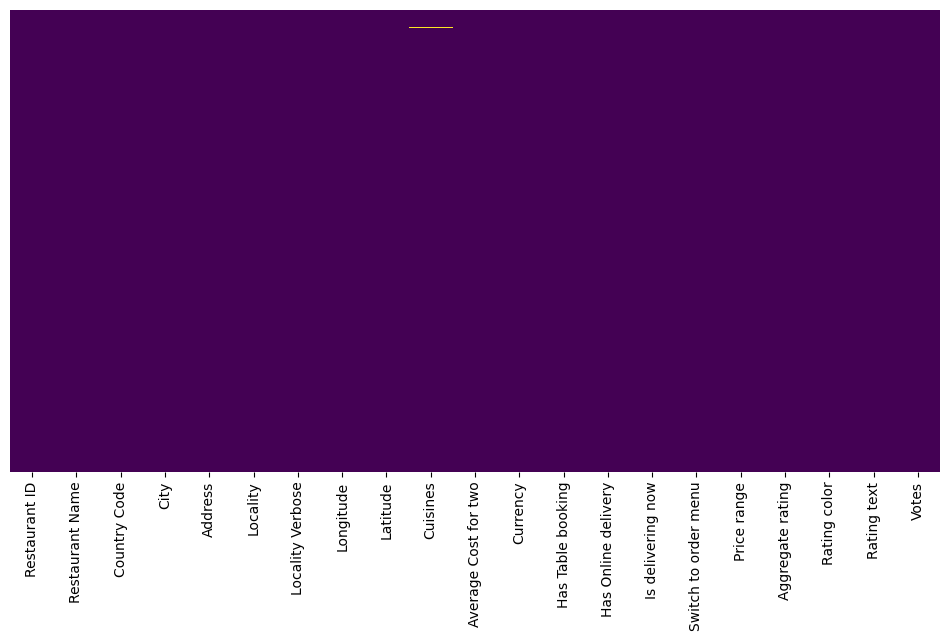

In [93]:
sns.heatmap(df.isnull() , yticklabels = False , cbar=False , cmap = 'viridis')

In [41]:
df_ = pd.read_excel('Country-Code.xlsx')
df_.head()

,Country Code,Country
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia


In [43]:
final_df = pd.merge(df , df_ , on = 'Country Code' , how = 'inner')

In [46]:
print(df.shape)
print(final_df.shape)
# Number of columns increased after merging both the datasets together !

(9551, 21)
(9551, 22)


In [70]:
country_value = final_df['Country'].value_counts().values
print(country_value)
country_names = final_df['Country'].value_counts().index
print(country_names)

[8652  434   80   60   60   60   40   34   24   22   21   20   20   20
    4]
Index(['India', 'United States', 'United Kingdom', 'Brazil', 'UAE',
       'South Africa', 'New Zealand', 'Turkey', 'Australia', 'Phillipines',
       'Indonesia', 'Singapore', 'Qatar', 'Sri Lanka', 'Canada'],
      dtype='object', name='Country')


([<matplotlib.patches.Wedge at 0x41ed4bed0>,
 [Text(-1.082974277862112, 0.1927867046480056, 'India'),
  Text(1.0772816964394372, -0.22240536530526556, 'United States'),
  Text(1.0995865232164619, -0.030157552300104404, 'United Kingdom')],
 [Text(-0.5907132424702428, 0.10515638435345759, '94.39%'),
  Text(0.5876081980578747, -0.12131201743923574, '4.73%'),
  Text(0.5997744672089791, -0.01644957398187513, '0.87%')])

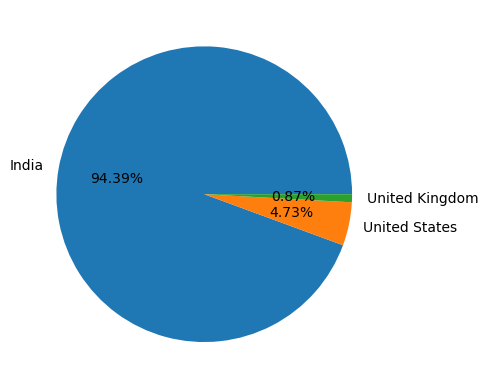

In [73]:
plt.pie( x = country_value[:3] , labels = country_names[:3] , autopct = '%1.2f%%')

In [74]:
# The piechart shows that the countries with highest number of zomato transactions are INDIA,USA,UK
# INDIA HAS MAJORITY OF THE TRANSACTIONS CONSTITUTING ABOUT 94.39%

In [75]:
corr = final_df.corr(numeric_only = True)

<Axes: >

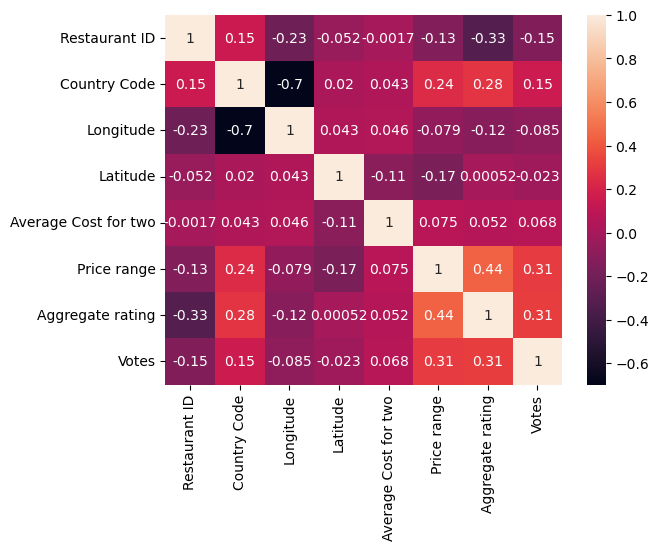

In [77]:
sns.heatmap(corr , annot = True )

**ANALYSIS ON RATINGS**

In [78]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [89]:
ratings = final_df.groupby(['Aggregate rating', 'Rating color', 'Rating text']).size().reset_index().rename(columns = {0:'Rating Count'})
ratings.head()

,Aggregate rating,Rating color,Rating text,Rating Count
0,0.0,White,Not rated,2148
1,1.8,Red,Poor,1
2,1.9,Red,Poor,2
3,2.0,Red,Poor,7
4,2.1,Red,Poor,15


<Axes: xlabel='Aggregate rating', ylabel='Rating Count'>

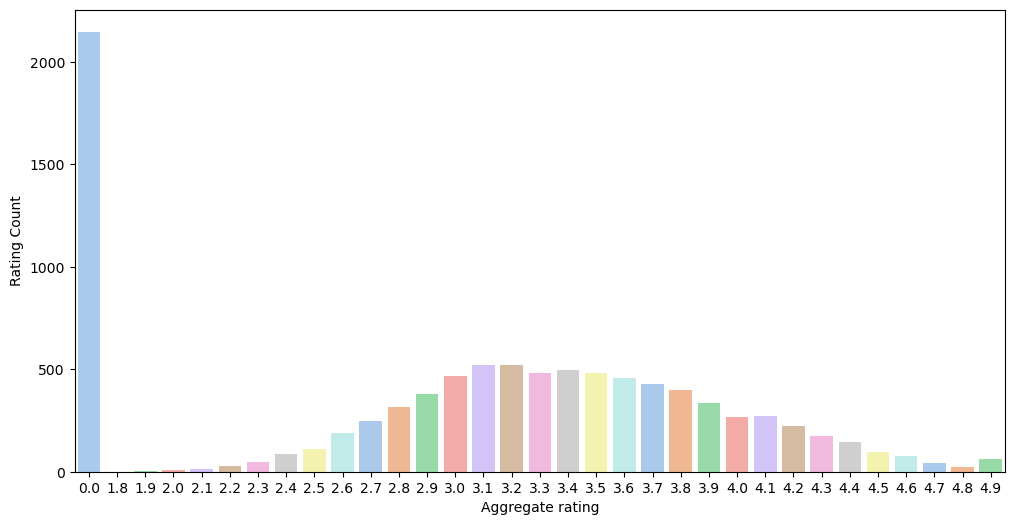

In [99]:
sns.barplot(x = ratings['Aggregate rating'] , y = ratings['Rating Count'] , palette = 'pastel' )

In [102]:
ratings['Rating color'].value_counts()

Rating color
Orange        10
Red            7
Yellow         5
Green          5
Dark Green     5
White          1
Name: count, dtype: int64

<Axes: xlabel='Aggregate rating', ylabel='Rating Count'>

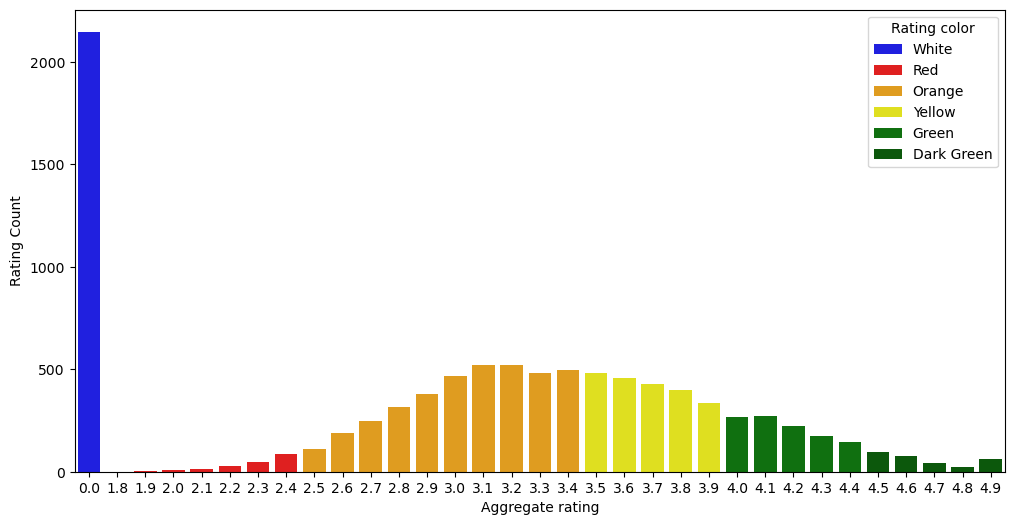

In [105]:
sns.barplot(x = ratings['Aggregate rating'] , y = ratings['Rating Count'] , hue = ratings['Rating color'] , palette = ['blue', 'red' , 'orange' , 'yellow' , 'green' , 'darkgreen'])

**OBSERVATIONS :**

**1.Most of the people did not rate at all which constitutes about 2000+ people.**

**2.The maximum ratings seem to fall in the range (2.5,3.4)**

In [106]:
# What are the names of the countries that have given 0 rating?

In [135]:
countries = final_df[final_df['Aggregate rating'] == 0]['Country'].unique().tolist()
countries

['Brazil', 'United States', 'India', 'United Kingdom']

In [142]:
final_df.groupby(['Aggregate rating' ,'Country']).size().reset_index().head()

,Aggregate rating,Country,0
0,0.0,Brazil,5
1,0.0,India,2139
2,0.0,United Kingdom,1
3,0.0,United States,3
4,1.8,India,1


In [143]:
# Find out which country uses which currency?

In [144]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [148]:
final_df.groupby(['Country' , 'Currency']).size().reset_index()

,Country,Currency,0
0,Australia,Dollar($),24
1,Brazil,Brazilian Real(R$),60
2,Canada,Dollar($),4
3,India,Indian Rupees(Rs.),8652
4,Indonesia,Indonesian Rupiah(IDR),21
5,New Zealand,NewZealand($),40
6,Phillipines,Botswana Pula(P),22
7,Qatar,Qatari Rial(QR),20
8,Singapore,Dollar($),20
9,South Africa,Rand(R),60


In [149]:
# Which countries have online service available?

In [153]:
final_df.groupby(['Country' , 'Has Online delivery']).size().reset_index().drop(columns = 0 , axis = 1)

,Country,Has Online delivery
0,Australia,No
1,Brazil,No
2,Canada,No
3,India,No
4,India,Yes
5,Indonesia,No
6,New Zealand,No
7,Phillipines,No
8,Qatar,No
9,Singapore,No


In [154]:
# Distribution of top 5 cities

In [165]:
city_name = final_df['City'].value_counts().index
city_count =  final_df['City'].value_counts().values

([<matplotlib.patches.Wedge at 0x42a7e2fd0>,
 [Text(-0.6145353730323402, 0.9123301350344637, 'New Delhi'),
  Text(0.06236774886414425, -1.0982305149200777, 'Gurgaon'),
  Text(0.878904221413572, -0.6614585169014024, 'Noida'),
  Text(1.0922218482114119, -0.1305811406354216, 'Faridabad'),
  Text(1.099946277419523, -0.010871374841004297, 'Ghaziabad')],
 [Text(-0.33520111256309465, 0.4976346191097074, '68.87%'),
  Text(0.03401877210771504, -0.5990348263200423, '14.07%'),
  Text(0.479402302589221, -0.36079555467349217, '13.59%'),
  Text(0.5957573717516791, -0.07122607671022996, '3.16%'),
  Text(0.5999706967742853, -0.00592984082236598, '0.31%')])

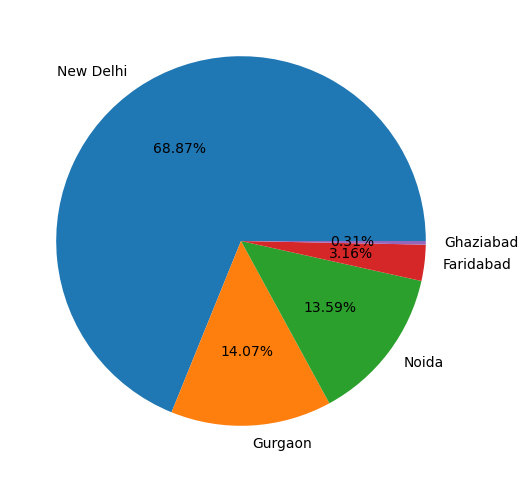

In [169]:
plt.pie( x = city_count[:5] , labels = city_name[:5] , autopct = '%1.2f%%' )

In [170]:
cuisines_name = final_df['Cuisines'].value_counts().index
cuisines_count =  final_df['Cuisines'].value_counts().values

([<matplotlib.patches.Wedge at 0x42a80f610>,
 [Text(0.4175822660282447, 1.0176566469584505, 'North Indian'),
  Text(-1.0901695016598902, 0.14673260595595905, 'North Indian, Chinese'),
  Text(-0.6326707688864324, -0.8998487085041855, 'Chinese'),
  Text(0.30487652953108235, -1.0569060042128076, 'Fast Food'),
  Text(1.003691693758835, -0.4501144119882426, 'North Indian, Mughlai')],
 [Text(0.22777214510631527, 0.5550854437955184, '37.61%'),
  Text(-0.5946379099963037, 0.08003596688506857, '20.53%'),
  Text(-0.3450931466653267, -0.49082656827501026, '14.22%'),
  Text(0.1662962888351358, -0.5764941841160768, '14.22%'),
  Text(0.5474681965957281, -0.24551695199358683, '13.42%')])

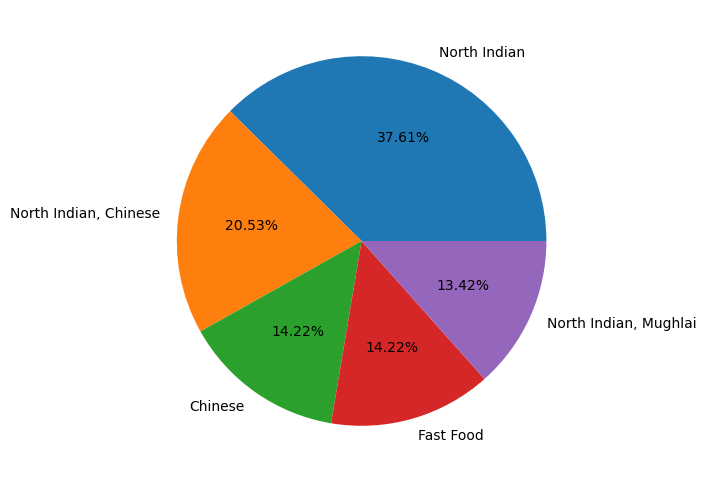

In [171]:
plt.pie( x = cuisines_count[:5] , labels = cuisines_name[:5] , autopct = '%1.2f%%' )